In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset
df = pd.read_csv("heart.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Basic EDA
df.isnull().sum()
df.duplicated().sum()

np.int64(1)

In [5]:
# Data Cleaning
df.drop_duplicates(inplace=True)

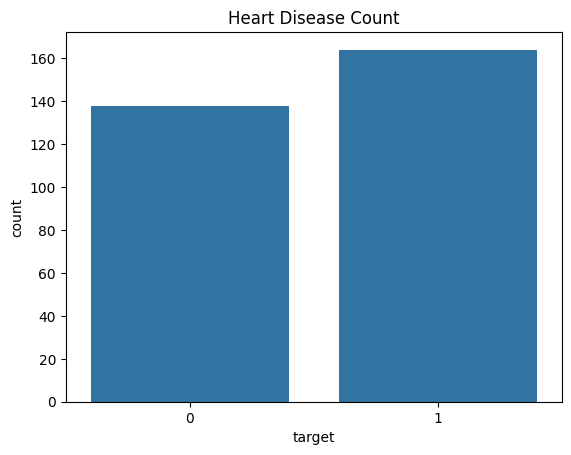

In [6]:
# EDA
# Target Variable Distribution
sns.countplot(x='target', data=df)
plt.title("Heart Disease Count")
plt.show()

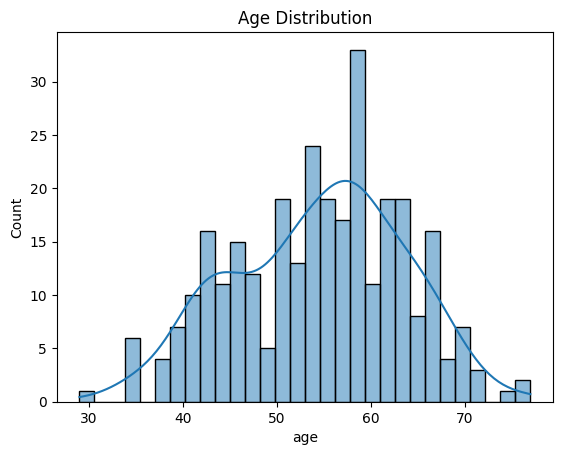

In [7]:
# Age Distribution
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

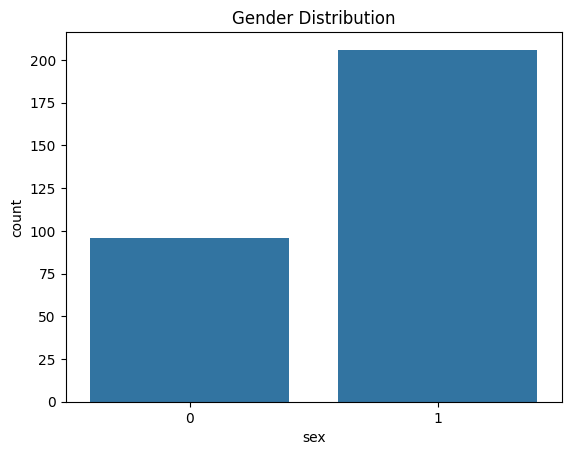

In [8]:
# Gender Distribution
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

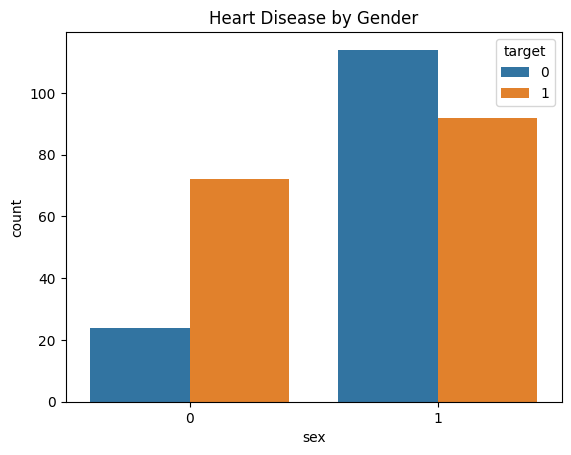

In [9]:
# Heart Disease by Gender
sns.countplot(x='sex', hue='target', data=df)
plt.title("Heart Disease by Gender")
plt.show()

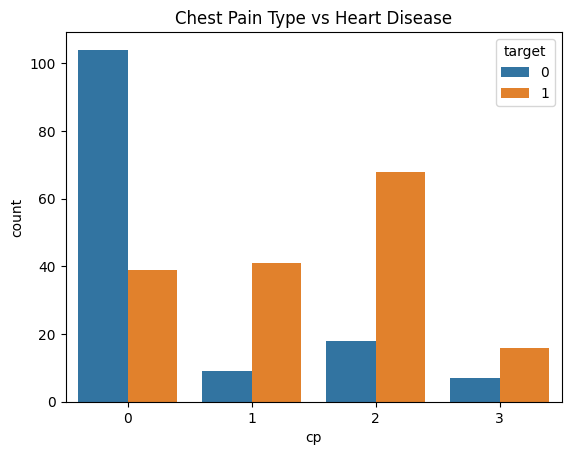

In [10]:
# Chest Pain Type Analysis
sns.countplot(x='cp', hue='target', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

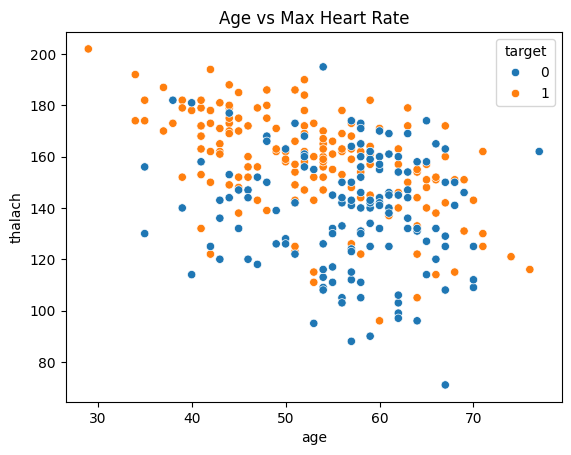

In [11]:
# Age vs Max Heart Rate
sns.scatterplot(x='age', y='thalach', hue='target', data=df)
plt.title("Age vs Max Heart Rate")
plt.show()

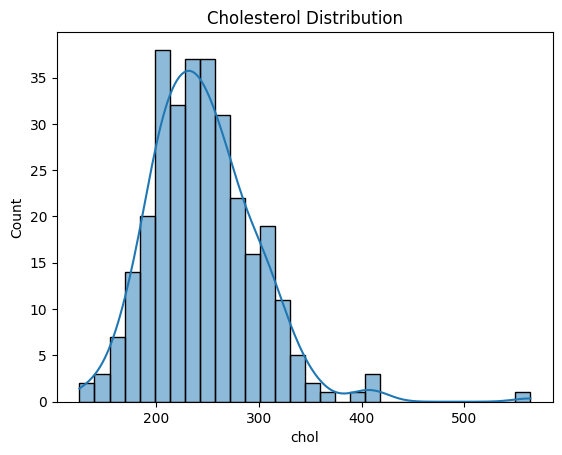

In [12]:
# Cholesterol Distribution
sns.histplot(df['chol'], bins=30, kde=True)
plt.title("Cholesterol Distribution")
plt.show()

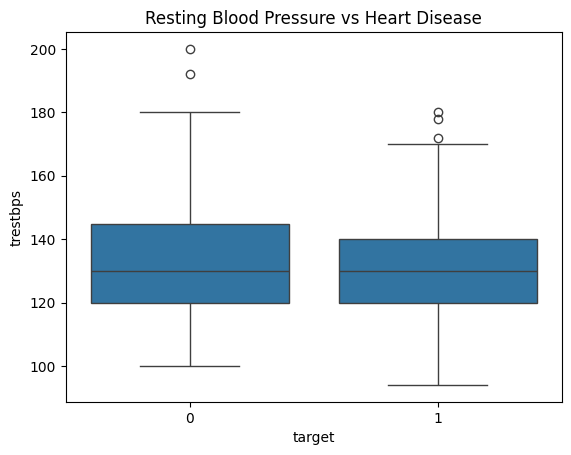

In [13]:
# Blood Pressure vs Target
sns.boxplot(x='target', y='trestbps', data=df)
plt.title("Resting Blood Pressure vs Heart Disease")
plt.show()

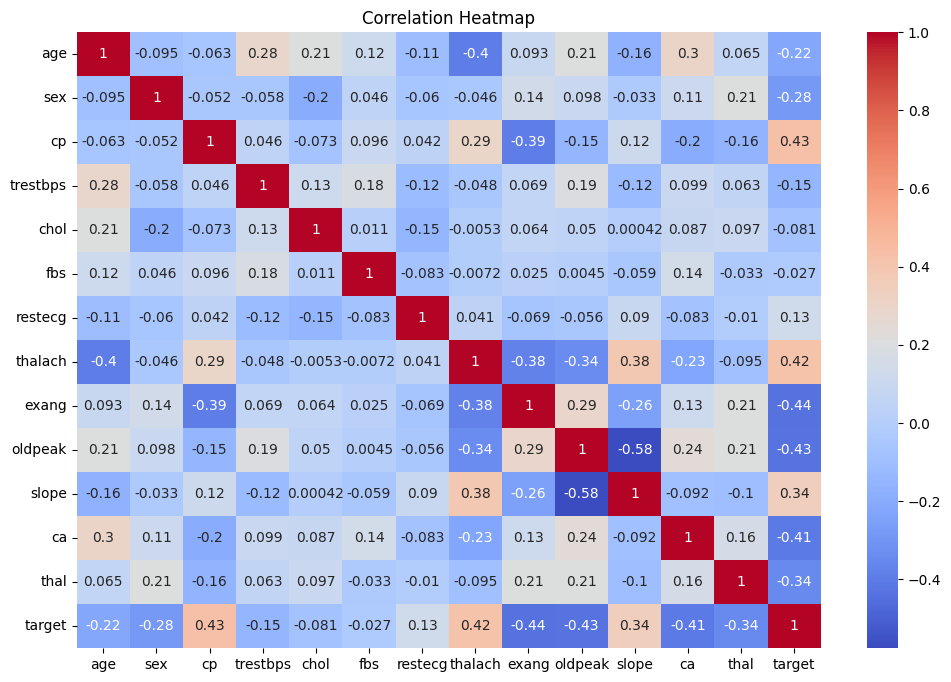

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

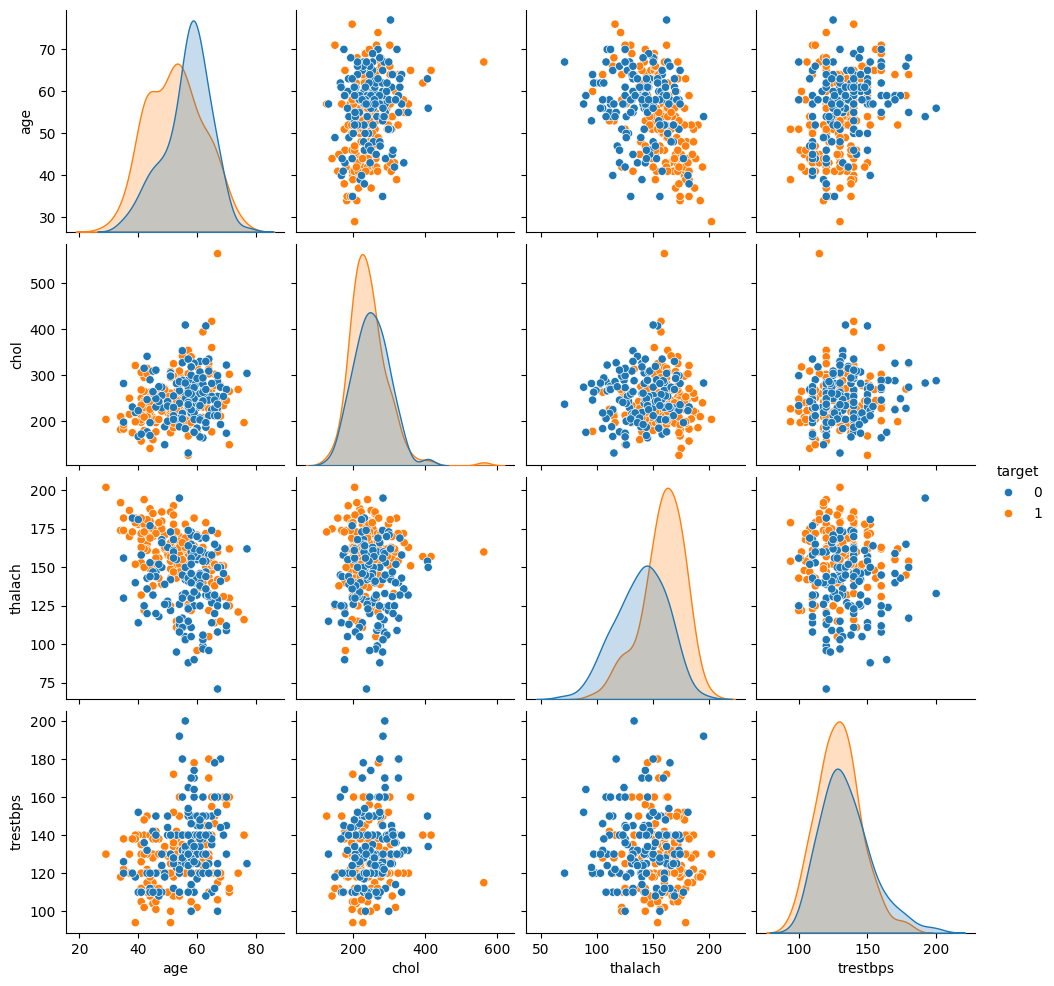

In [15]:
# Pairplot
sns.pairplot(df[['age','chol','thalach','trestbps','target']], hue='target')
plt.show()

In [16]:
# Data Preprocessing
X = df.drop('target', axis=1)
y = df['target']

In [17]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

In [20]:
# Train Multiple Supervised Models
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB()
}

In [21]:
# Import required functions from sklearn.metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train and Evaluate All Models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    results.append([name, accuracy])
    
    print(f"{name}")
    print("Accuracy:", accuracy)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("="*50)

Logistic Regression
Accuracy: 0.819672131147541
[[24  5]
 [ 6 26]]
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

KNN
Accuracy: 0.9180327868852459
[[28  1]
 [ 4 28]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        29
           1       0.97      0.88      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61

Decision Tree
Accuracy: 0.7704918032786885
[[25  4]
 [10 22]]
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        29
           1       0.85      0.69      0.76        32

 

In [22]:
# Compare Model Performance
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
1,KNN,0.918033
5,Naive Bayes,0.885246
4,SVM,0.868852
3,Random Forest,0.868852
0,Logistic Regression,0.819672
2,Decision Tree,0.770492


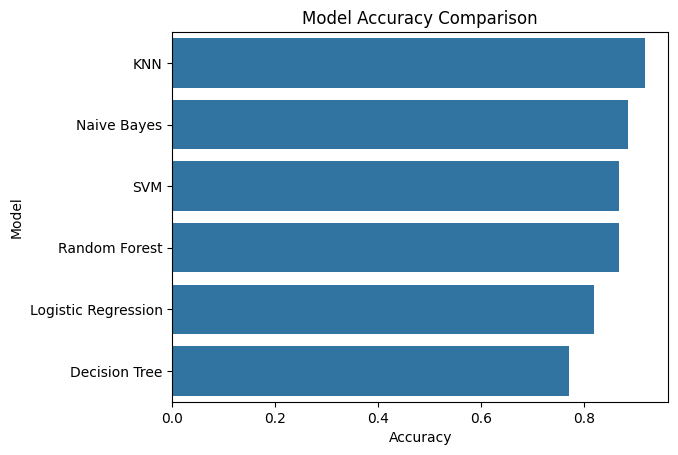

In [23]:
# Visualize Model Accuracy
sns.barplot(x="Accuracy", y="Model", data=results_df)
plt.title("Model Accuracy Comparison")
plt.show()

In [24]:
# Best Model Selection
best_model = results_df.iloc[0]
print("Best Model:")
print(best_model)

Best Model:
Model            KNN
Accuracy    0.918033
Name: 1, dtype: object


In [25]:
import joblib
joblib.dump(models["KNN"],"KNN_heart.pkl")
joblib.dump(scaler,"scaler.pkl")
# Fixed: tolist() is now called as a method on X.columns, and removed the extra comma
joblib.dump(X.columns.tolist(),"columns.pkl")

['columns.pkl']